In [10]:
import os
import re
import numpy as np
from skimage import io
from tqdm import tqdm

def parse_filename(filename):
    """Extracts x, y positions from filenames formatted as SCC_mask_patchX-Y.tif"""
    match = re.search(r'_patch(\d+)-(\d+)\.tif$', filename)
    if match:
        return int(match.group(2)), int(match.group(1))
    return None

def load_images_and_positions(folder):
    """Loads images and determines the grid size."""
    images = {}
    max_x, max_y = 0, 0
    
    for filename in os.listdir(folder):
        if filename.endswith('.tif'):
            pos = parse_filename(filename)
            print(pos)
            if pos:
                x, y = pos
                img = io.imread(os.path.join(folder, filename))
                images[(x, y)] = img
                max_x, max_y = max(max_x, x), max(max_y, y)
    
    return images, max_x + 1, max_y + 1  # Ensure full coverage

def stitch_images(folder, output_path, tile_size=(512, 512)):
    """Stitches image tiles into a full image, filling missing tiles with blank images."""
    images, width, height = load_images_and_positions(folder)
    blank_tile = np.zeros(tile_size, dtype=np.uint8)
    
    stitched_image = np.zeros((height * tile_size[1], width * tile_size[0]), dtype=np.uint8)
    
    for x in tqdm(range(width), desc="Stitching images"):
        for y in range(height):
            tile = images.get((x, y), blank_tile)
            stitched_image[y * tile_size[1]:(y + 1) * tile_size[1], x * tile_size[0]:(x + 1) * tile_size[0]] = tile
    
    os.makedirs(os.path.dirname(output_path), exist_ok=True)  # Ensure output directory exists
    io.imsave(output_path, stitched_image)
    print(f"Stitched image saved to: {output_path}")

# Example usage
data_path = 'data/train/masks/'
output_file = 'stitched/stitched_mask.tif'
stitch_images(data_path, output_file)

(9, 8)
(10, 23)
(10, 8)
(13, 9)
(5, 16)
(15, 4)
(12, 8)
(10, 5)
(15, 19)
(8, 18)
(7, 16)
(15, 18)
(14, 14)
(15, 3)
(13, 8)
(6, 21)
(13, 13)
(4, 17)
(5, 18)
(18, 5)
(9, 7)
(11, 20)
(2, 14)
(7, 23)
(13, 4)
(14, 21)
(9, 5)
(16, 11)
(8, 17)
(8, 10)
(1, 20)
(9, 20)
(2, 17)
(12, 7)
(12, 9)
(3, 9)
(4, 10)
(18, 4)
(5, 17)
(15, 8)
(5, 14)
(15, 16)
(4, 22)
(16, 9)
(6, 11)
(7, 19)
(11, 13)
(6, 24)
(8, 19)
(8, 22)
(13, 14)
(16, 24)
(16, 22)
(13, 20)
(10, 20)
(7, 21)
(5, 11)
(15, 6)
(6, 14)
(6, 22)
(10, 24)
(7, 9)
(13, 15)
(10, 13)
(17, 4)
(14, 6)
(6, 5)
(15, 20)
(5, 12)
(8, 14)
(11, 16)
(1, 19)
(2, 8)
(4, 11)
(15, 23)
(6, 16)
(3, 14)
(3, 23)
(16, 14)
(3, 8)
(2, 16)
(2, 10)
(8, 5)
(16, 0)
(7, 22)
(7, 18)
(12, 17)
(8, 15)
(14, 13)
(9, 14)
(8, 23)
(8, 7)
(12, 5)
(17, 0)
(6, 20)
(8, 6)
(2, 15)
(17, 13)
(7, 10)
(17, 3)
(11, 14)
(13, 16)
(9, 17)
(3, 22)
(5, 9)
(16, 5)
(11, 17)
(8, 16)
(3, 12)
(12, 22)
(15, 22)
(12, 23)
(15, 9)
(16, 4)
(16, 3)
(17, 19)
(12, 11)
(6, 12)
(18, 2)
(5, 24)
(13, 10)
(19, 1)
(1

Stitching images: 100%|██████████| 20/20 [00:00<00:00, 259.18it/s]


Stitched image saved to: stitched/stitched_mask.tif


/home/ec2-user/anaconda3/envs/python3/lib/python3.10/site-packages/skimage/_shared/utils.py:328: UserWarning: stitched/stitched_mask.tif is a low contrast image
  return func(*args, **kwargs)


In [13]:
!pip install rasterio

  Using cached rasterio-1.4.3-cp310-cp310-manylinux_2_17_x86_64.manylinux2014_x86_64.whl.metadata (9.1 kB)
  Using cached affine-2.4.0-py3-none-any.whl.metadata (4.0 kB)
  Using cached cligj-0.7.2-py3-none-any.whl.metadata (5.0 kB)
  Using cached click_plugins-1.1.1-py2.py3-none-any.whl.metadata (6.4 kB)
Using cached rasterio-1.4.3-cp310-cp310-manylinux_2_17_x86_64.manylinux2014_x86_64.whl (22.2 MB)
Using cached cligj-0.7.2-py3-none-any.whl (7.1 kB)
Using cached affine-2.4.0-py3-none-any.whl (15 kB)
Using cached click_plugins-1.1.1-py2.py3-none-any.whl (7.5 kB)


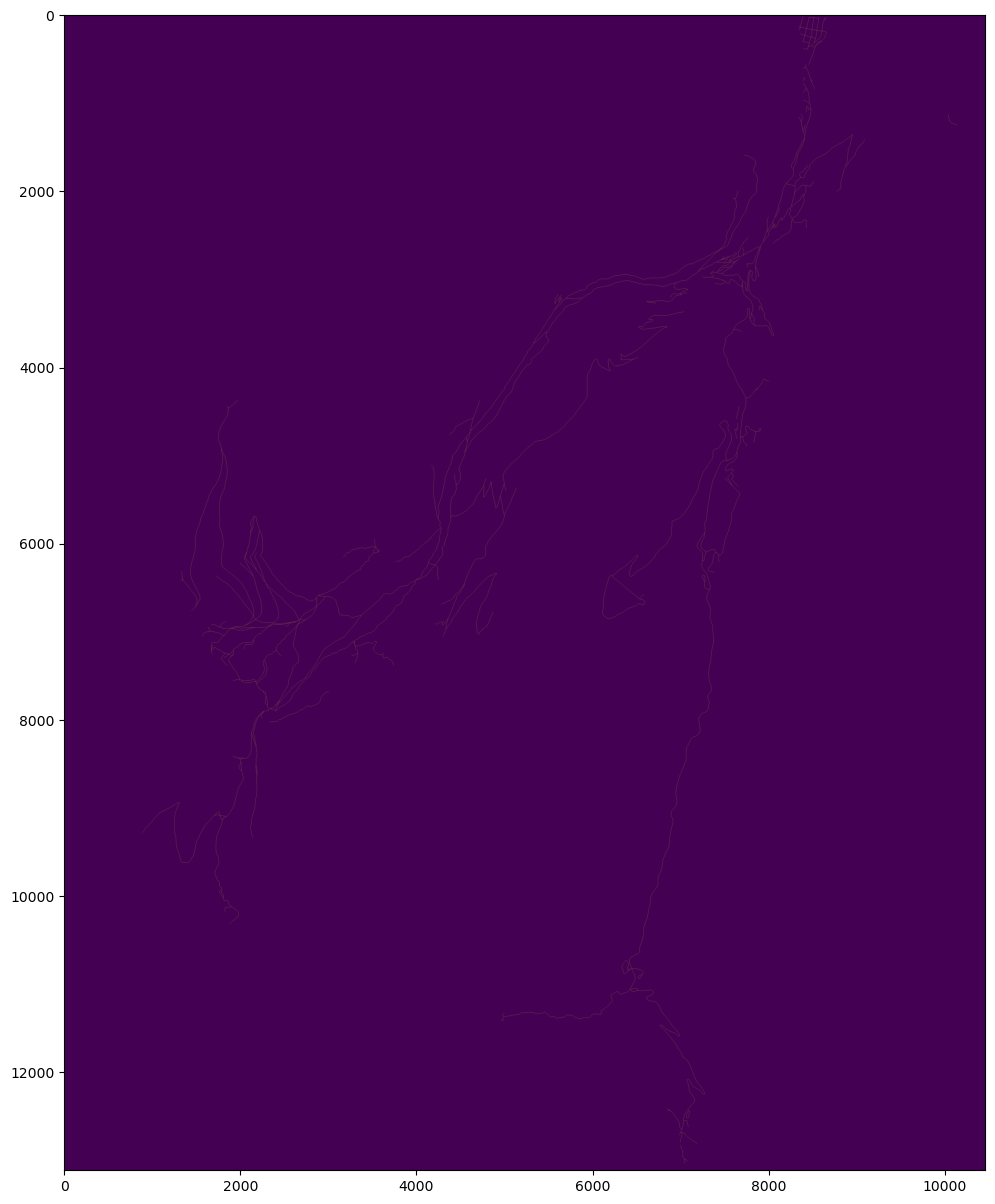

In [16]:
import rasterio
roads_path = "data/raw/South_Clear_Creek/Roads_Boundary/South_Clear_Creek_Roads_Mask.tif"
with rasterio.open(roads_path) as roads_dataset:
    roads_mask = roads_dataset.read()
plt.figure(figsize=(15,15))
plt.imshow(roads_mask.transpose(1, 2, 0))
plt.show()

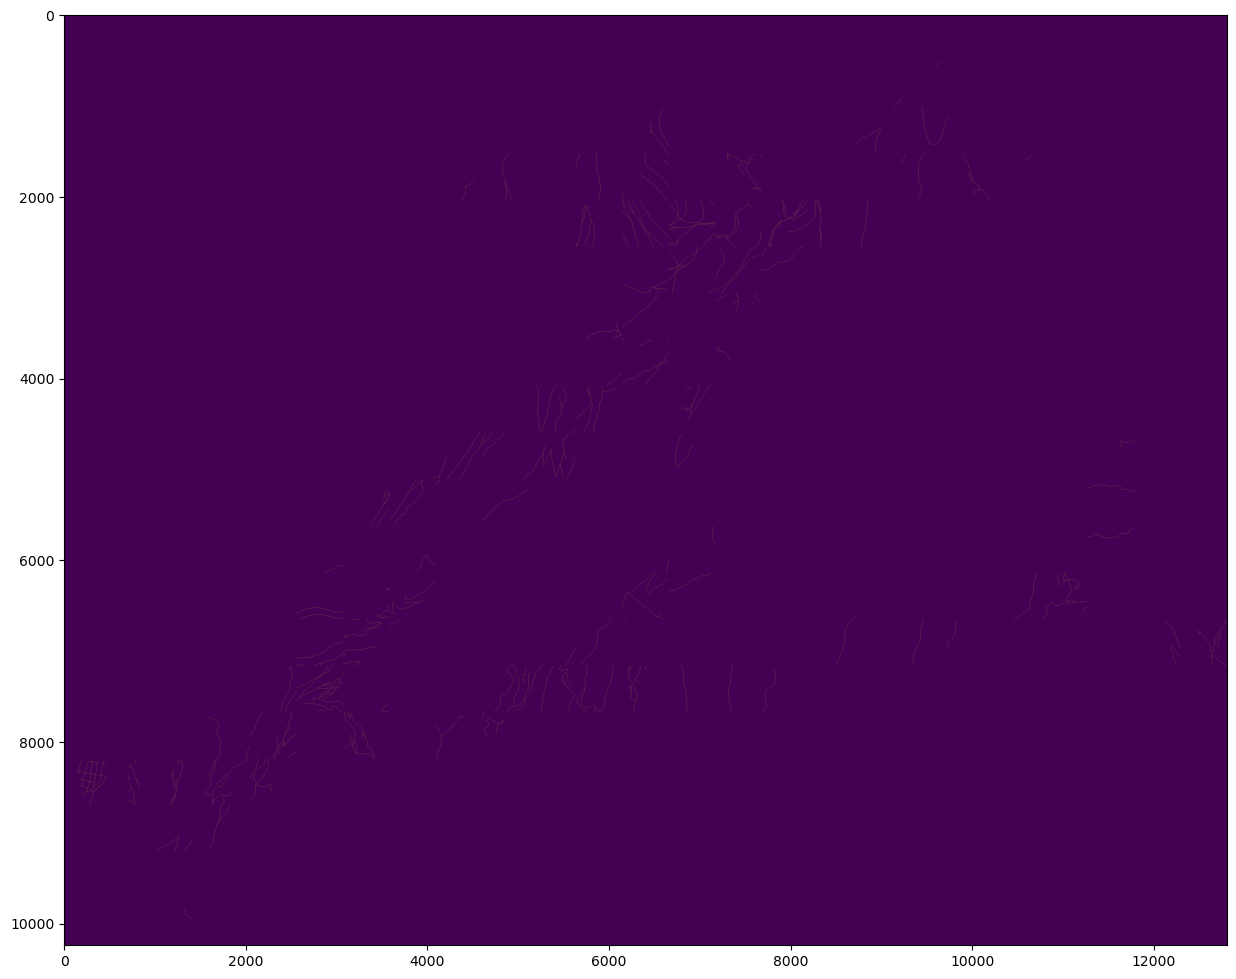

In [18]:
import rasterio
roads_path = "stitched/stitched_mask.tif"
with rasterio.open(roads_path) as roads_dataset:
    roads_mask = roads_dataset.read()
plt.figure(figsize=(15,15))
plt.imshow(roads_mask.transpose(1, 2, 0))
plt.show()

In [17]:
import os
import re
import numpy as np
import rasterio
from rasterio.transform import from_origin
from tqdm import tqdm

def parse_filename(filename):
    """Extract x, y positions from filenames formatted as SCC_mask_patchX-Y.tif"""
    match = re.search(r'_patch(\d+)-(\d+)\.tif$', filename)
    if match:
        return int(match.group(1)), int(match.group(2))
    return None

def load_images_and_positions(folder):
    """Loads images, determines grid size, and extracts metadata from the first image."""
    images = {}
    max_x, max_y = 0, 0
    tile_size = None
    metadata = None

    for filename in os.listdir(folder):
        if filename.endswith('.tif'):
            pos = parse_filename(filename)
            if pos:
                x, y = pos
                file_path = os.path.join(folder, filename)

                with rasterio.open(file_path) as src:
                    img = src.read(1)  # Read first band
                    if tile_size is None:
                        tile_size = (src.height, src.width)
                        metadata = src.meta.copy()  # Store metadata from first image

                images[(x, y)] = img
                max_x, max_y = max(max_x, x), max(max_y, y)

    return images, max_x + 1, max_y + 1, tile_size, metadata

def stitch_images(folder, output_path):
    """Stitches image tiles into a full image, preserving metadata."""
    images, width, height, tile_size, metadata = load_images_and_positions(folder)
    
    if tile_size is None or metadata is None:
        raise ValueError("No valid images found in the directory.")

    blank_tile = np.zeros(tile_size, dtype=np.uint8)

    # Create stitched image array
    stitched_image = np.zeros((height * tile_size[0], width * tile_size[1]), dtype=np.uint8)

    for (x, y), tile in tqdm(images.items(), desc="Stitching images"):
        stitched_image[y * tile_size[0]:(y + 1) * tile_size[0], x * tile_size[1]:(x + 1) * tile_size[1]] = tile

    # Update metadata
    metadata.update({
        "height": stitched_image.shape[0],
        "width": stitched_image.shape[1],
        "transform": from_origin(0, 0, tile_size[1], tile_size[0])  # Adjust as needed
    })

    # Ensure output directory exists
    os.makedirs(os.path.dirname(output_path), exist_ok=True)

    # Save stitched image with updated metadata
    with rasterio.open(output_path, "w", **metadata) as dst:
        dst.write(stitched_image, 1)  # Write first band

    print(f"Stitched image saved to: {output_path}")

# Example usage
data_path = 'data/train/masks/'
output_file = 'stitched/stitched_mask.tif'
stitch_images(data_path, output_file)


Stitching images: 100%|██████████| 276/276 [00:00<00:00, 4246.45it/s]


Stitched image saved to: stitched/stitched_mask.tif
